In [110]:
from pathlib import Path
import numpy as np
from snirf import Snirf
import mne
from mne_nirs.io import write_raw_snirf
from snirf import validateSnirf
import os
import snirf
from mne.io import read_raw_nirx, read_raw_snirf
from mne.preprocessing.nirs import beer_lambert_law, optical_density
from numpy.testing import assert_allclose
from pathlib import Path
import os

import matplotlib.pyplot as plt
import mne
import numpy as np
from nilearn.plotting import plot_design_matrix

import mne_nirs
from mne_nirs.channels import get_long_channels, get_short_channels, picks_pair_to_idx
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm

# Convert .snirf generated from homer3 to mne compatible .snirf

1. Take Homer3 HbO/HbR/HbT SNIRF
2. Drop HbT channels
3. Keep measurementList as a proper pysnirf2 IndexedGroup
4. Save a new SNIRF that mne.io.read_raw_snirf can read as hbo/hbr
5. Fix landmarks in .snirf file
6. Write missing wavelenthgs and rewrite .snirf file using write_raw_snirf().


In [111]:
from pathlib import Path
import numpy as np

import mne
from mne_nirs.io.snirf import write_raw_snirf

from snirf import Snirf
from snirf import validateSnirf


# ============================================================
# SETTINGS YOU EDIT
# ============================================================
INPUT_DIR = Path(
    "/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne"
)

# Final outputs will be here:
OUTPUT_DIR = INPUT_DIR / "mne_derived"

# Temporary working dir (auto-created)
TMP_DIR = OUTPUT_DIR / ".tmp_snirf_work"

# Wavelengths (from your MATLAB probe.GetWls())
LAMBDA_HBO = 751.0
LAMBDA_HBR = 843.0

PATTERN = "*.snirf"
# ============================================================


def keep_hbo_hbr_only(in_fname: Path, out_fname: Path) -> None:
    """Drop non-HbO/HbR channels by editing measurementList + dataTimeSeries using pysnirf2."""
    snirf = Snirf(str(in_fname))
    nirs = snirf.nirs[0]
    data = nirs.data[0]
    ml = data.measurementList

    labels = [str(ml[i].dataTypeLabel) for i in range(len(ml))]
    keep_mask = np.array([(lab == "HbO") or (lab == "HbR") for lab in labels], dtype=bool)

    n_total = len(labels)
    ts = np.asarray(data.dataTimeSeries)

    if ts.shape[1] != n_total:
        raise RuntimeError(
            f"{in_fname.name}: dataTimeSeries has {ts.shape[1]} cols but measurementList has {n_total}"
        )

    data.dataTimeSeries = ts[:, keep_mask]

    for i in range(n_total - 1, -1, -1):
        if not keep_mask[i]:
            del ml[i]

    snirf.save(str(out_fname))


def remove_landmarks_inplace(snirf_path: Path) -> None:
    """Remove probe landmarks in-place."""
    with Snirf(str(snirf_path), "r+") as snirf:
        probe = snirf.nirs[0].probe
        probe.landmarkPos3D = None
        probe.landmarkLabels = None
        snirf.save()


def fix_nan_wavelengths_and_write_clean(in_snirf: Path, out_clean: Path) -> None:
    """Read with MNE, fix NaN wavelengths in info['chs'][...]['loc'][9], write clean SNIRF."""
    raw = mne.io.read_raw_snirf(str(in_snirf), preload=True)

    for ch in raw.info["chs"]:
        wl = ch["loc"][9]
        if not np.isfinite(wl):
            name = ch["ch_name"].lower()
            if name.endswith(" hbo"):
                ch["loc"][9] = float(LAMBDA_HBO)
            elif name.endswith(" hbr"):
                ch["loc"][9] = float(LAMBDA_HBR)
            else:
                ch["loc"][9] = float(LAMBDA_HBO)

    write_raw_snirf(raw, str(out_clean))


def validate_snirf(file_path: Path) -> None:
    res = validateSnirf(str(file_path))
    res.display()
    if not res.is_valid():
        raise RuntimeError(f"SNIRF validation failed: {file_path.name}")


def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    TMP_DIR.mkdir(parents=True, exist_ok=True)

    files = sorted(INPUT_DIR.glob(PATTERN))
    if not files:
        raise RuntimeError(f"No files matched {PATTERN} in {INPUT_DIR}")

    print(f"\nInput folder:  {INPUT_DIR}")
    print(f"Output folder: {OUTPUT_DIR}")
    print(f"Found {len(files)} snirf files.\n")

    ok, failed = 0, 0

    for in_fname in files:
        tmp_mne = TMP_DIR / f"{in_fname.stem}__tmp_mne.snirf"
        out_clean = OUTPUT_DIR / f"{in_fname.stem}_mne_clean.snirf"

        try:
            # 1) HbO/HbR only -> temp file
            keep_hbo_hbr_only(in_fname, tmp_mne)

            # 2) Remove landmarks (temp file)
            remove_landmarks_inplace(tmp_mne)

            # 3) Fix NaN wavelengths -> FINAL output
            fix_nan_wavelengths_and_write_clean(tmp_mne, out_clean)

            # 4) Validate + quick load
            _ = mne.io.read_raw_snirf(str(out_clean), preload=False)
            validate_snirf(out_clean)

            print(f"✅ {in_fname.name} -> {out_clean.name}")
            ok += 1

        except Exception as e:
            print(f"❌ {in_fname.name} FAILED: {e}")
            failed += 1

        finally:
            # Always try to delete temp file
            try:
                if tmp_mne.exists():
                    tmp_mne.unlink()
            except Exception:
                pass

    # Try to remove temp dir if empty
    try:
        if TMP_DIR.exists() and not any(TMP_DIR.iterdir()):
            TMP_DIR.rmdir()
    except Exception:
        pass

    print(f"\nDone. Success: {ok}, Failed: {failed}")
    print(f"Final outputs are in: {OUTPUT_DIR}\n")


if __name__ == "__main__":
    main()



Input folder:  /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne
Output folder: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived
Found 4 snirf files.

Loading /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/.tmp_snirf_work/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb__tmp_mne.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 1739  =      0.000 ...   173.900 secs...
Loading /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_

# GLM for a single run (sample)

Loading SNIRF: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
Loading /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 1739  =      0.000 ...   173.900 secs...
<RawSNIRF | sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf, 92 x 1740 (174.0 s), ~1.3 MiB, data loaded>
Channel types: ['hbo', 'hbr']
Onset:  [ 23.049465  69.025444 115.034848]
Duration:  [36. 36. 36.]
Description:  ['arith' 'arith1' 'control']
Detected haemoglobin data → using as-is
Remaining channels: 88
Design matrix columns:

/var/folders/57/27nbkr8d6tjbj5ht598xbyzm0000gn/T/ipykernel_53127/2096872778.py:83: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


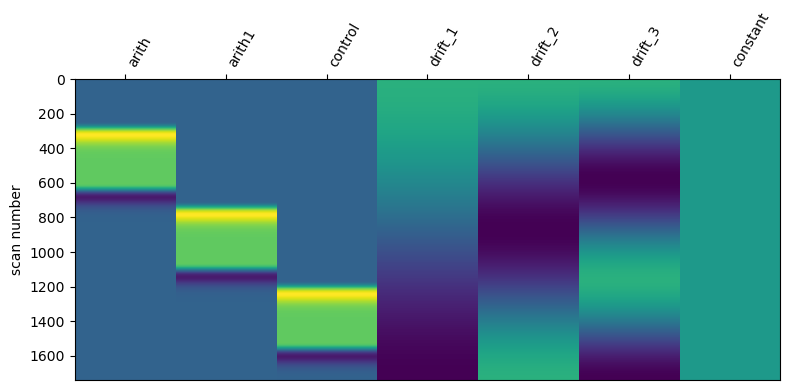

Fitting GLM...
variable Condition   df           mse   p_value        se         t     theta  \
280          arith  7.0  8.419014e-12  0.392988  0.000008  0.910182  0.000008   
281         arith1  7.0  8.419014e-12  0.128750  0.000008 -1.721955 -0.000015   
282       constant  7.0  8.419014e-12  0.502632  0.000006  0.706632  0.000004   
283        control  7.0  8.419014e-12  0.000054  0.000008 -8.668734 -0.000073   
284        drift_1  7.0  8.419014e-12  0.000487  0.000228 -6.108486 -0.001392   

variable  Source  Detector Chroma  Significant    ch_name  
280            1         1    hbo        False  S1_D1 hbo  
281            1         1    hbo        False  S1_D1 hbo  
282            1         1    hbo        False  S1_D1 hbo  
283            1         1    hbo         True  S1_D1 hbo  
284            1         1    hbo         True  S1_D1 hbo  
Saved GLM results to: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf

In [112]:
# glm_from_snirf.py

from pathlib import Path

import mne
import pandas as pd

from mne.preprocessing.nirs import optical_density, beer_lambert_law
from mne_nirs.channels import get_long_channels
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm

# -----------------------------
# 0) INPUTS (EDIT THESE)
# -----------------------------
snirf_path = Path("/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf")
out_csv1 = snirf_path.with_name(snirf_path.stem + "_glm_mne.csv")
out_csv    = Path(out_csv1)



# -----------------------------
# 1) LOAD SNIRF
# -----------------------------
print(f"Loading SNIRF: {snirf_path}")
raw = mne.io.read_raw_snirf(snirf_path, preload=True)
print(raw)  # quick sanity check
print("Channel types:", raw.get_channel_types(unique=True))
print("Onset: ", raw.annotations.onset)
print("Duration: ", raw.annotations.duration)
print("Description: ", raw.annotations.description)

# Typical block length for your task (seconds)
STIM_DUR = raw.annotations.duration[0]   # change to your actual block duration

# -----------------------------
# 2) ENSURE HAEMOGLOBIN DATA
# -----------------------------
ch_types = raw.get_channel_types(unique=True)

if "fnirs_cw_amplitude" in ch_types:
    # Case A: SNIRF still contains intensity → convert to HbO/HbR
    print("Detected intensity data → converting to HbO/HbR")
    raw_od = optical_density(raw)
    raw_haemo = beer_lambert_law(raw_od)
elif any(ct in ("hbo", "hbr") for ct in ch_types):
    # Case B: already haemoglobin (typical for your Homer3 export)
    print("Detected haemoglobin data → using as-is")
    raw_haemo = raw.copy()
else:
    raise RuntimeError(
        "Unexpected channel types. Expected 'fnirs_cw_amplitude' or 'hbo'/'hbr'."
    )

# -----------------------------
# 3) KEEP ONLY LONG CHANNELS
# -----------------------------
# Removes short-separation channels; default 1.5–4.5 cm. 
raw_haemo = get_long_channels(raw_haemo)
print("Remaining channels:", len(raw_haemo.ch_names))

# (Optional) extra filter here if you *haven't* prefiltered in Homer3.
# raw_haemo = raw_haemo.filter(0.01, 0.2, verbose=False)

# -----------------------------
# 4) DESIGN MATRIX
# -----------------------------
# Uses raw_haemo.annotations (from SNIRF stim) to build regressors.
# Each unique description becomes a regressor. 
design_matrix = make_first_level_design_matrix(
    raw_haemo,
    stim_dur=STIM_DUR,
    hrf_model="glover"    # canonical HRF, like SPM
)

print("Design matrix columns:", list(design_matrix.columns))
print(design_matrix.head())

# If you have nilearn installed, you can visualise the design:
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
plot_design_matrix(design_matrix, ax=ax)
fig.tight_layout()
plt.show()

# -----------------------------
# 5) RUN GLM
# -----------------------------
# Wrapper around Nilearn's GLM; default AR(1) noise model. 
print("Fitting GLM...")
glm_est = run_glm(raw_haemo, design_matrix)

# glm_est is a RegressionResults object with GLM fits for all channels. 

# -----------------------------
# 6) EXPORT RESULTS
# -----------------------------
# Converts all GLM results to a tidy DataFrame:
# one row per (channel, condition, chroma) with theta, t, p, etc. 
df = glm_est.to_dataframe()
print(df.head())

df.to_csv(out_csv, index=False)
print(f"Saved GLM results to: {out_csv}")


# Plot glm data from csv 

Read MNE-NIRS GLM results saved with RegressionResults.to_dataframe() and generate plots.

Loading GLM results from: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean_glm_mne.csv

Columns in file:
['Condition', 'df', 'mse', 'p_value', 'se', 't', 'theta', 'Source', 'Detector', 'Chroma', 'Significant', 'ch_name']

Unique conditions in CSV:
['arith', 'arith1', 'constant', 'control', 'drift_1', 'drift_2', 'drift_3']

Unique chroma in CSV:
['hbo', 'hbr']

Number of significant channels (p < 0.050) per condition & chroma:
Condition Chroma  n_sig_channels
    arith    hbo              15
    arith    hbr              29
   arith1    hbo              13
   arith1    hbr              28
 constant    hbo               4
 constant    hbr              15
  control    hbo              38
  control    hbr              35
  drift_1    hbo              35
  drift_1    hbr              30
  d

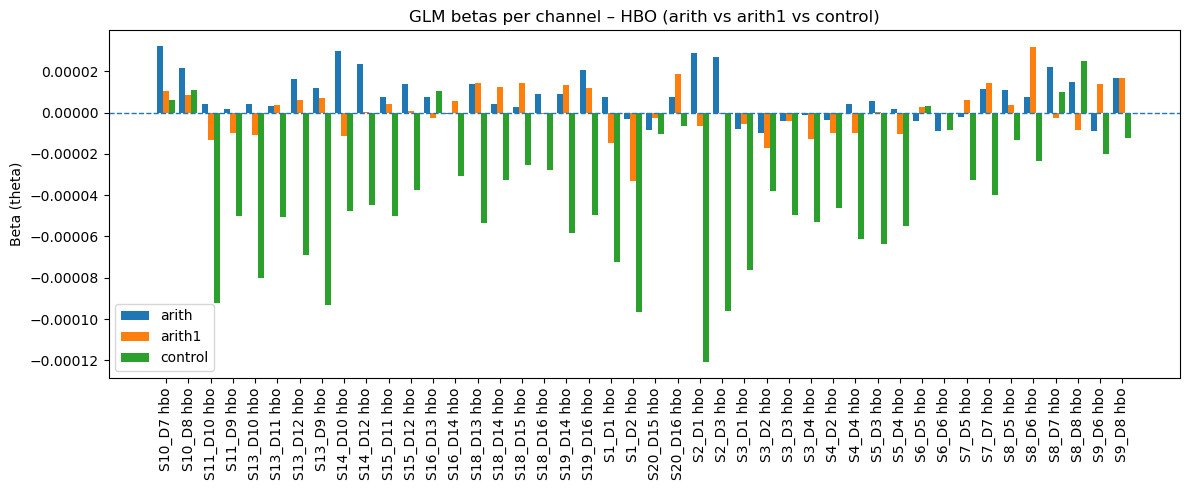

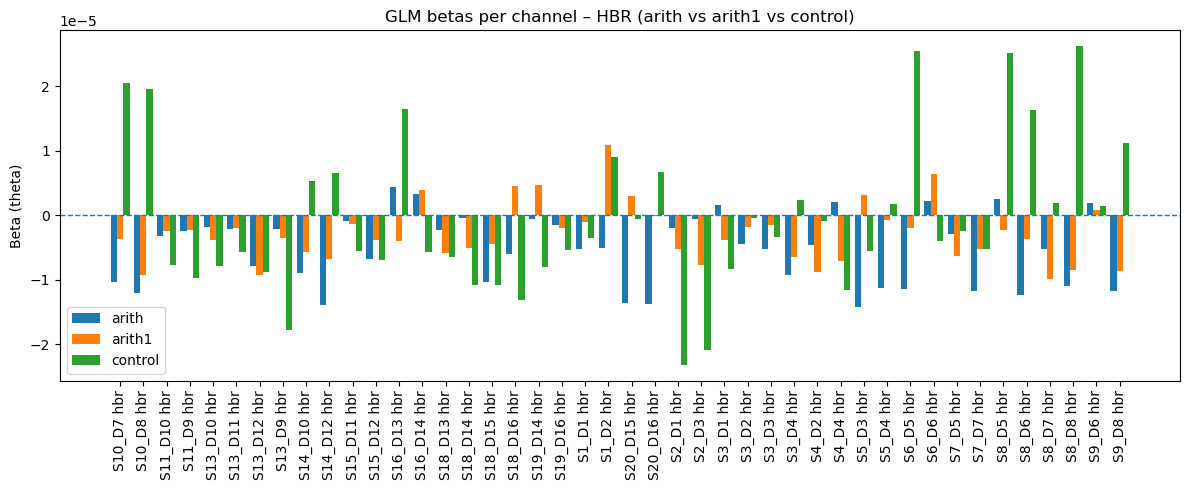


Creating heatmap of HbO betas (arith/arith1/control)...


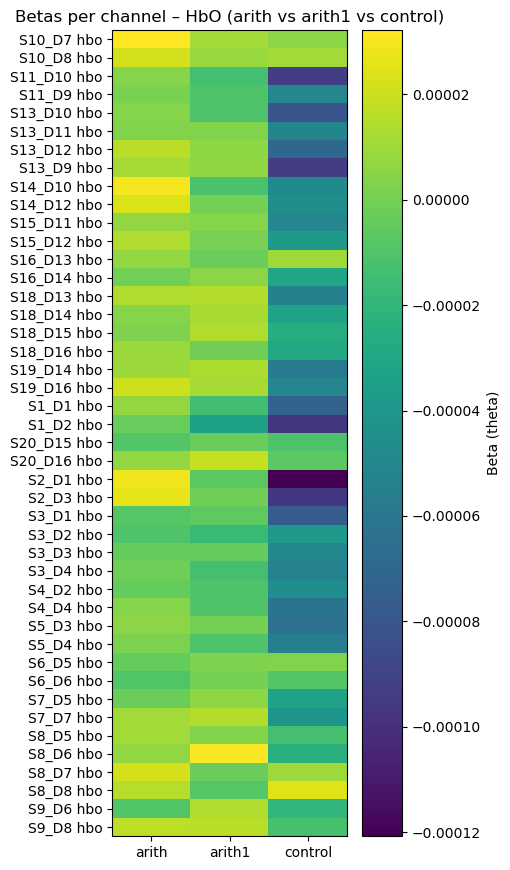


Creating volcano-style scatter for 'arith' and 'arith1'...


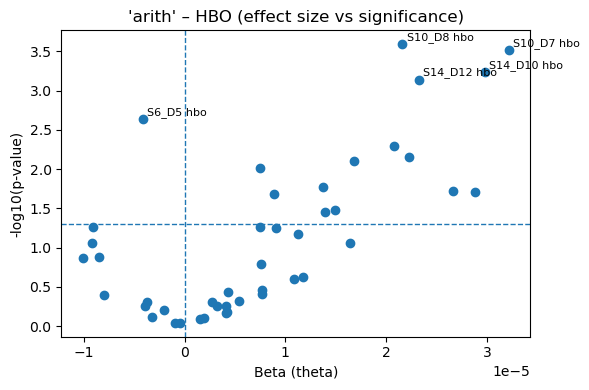

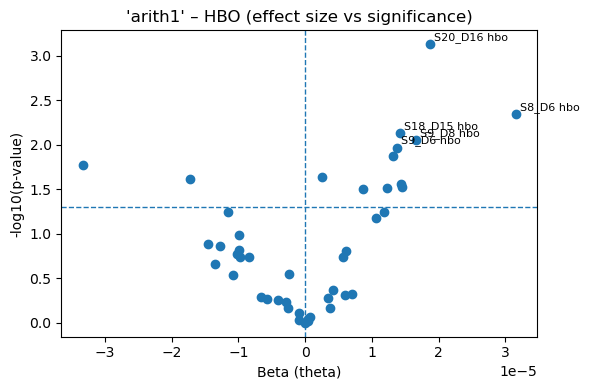

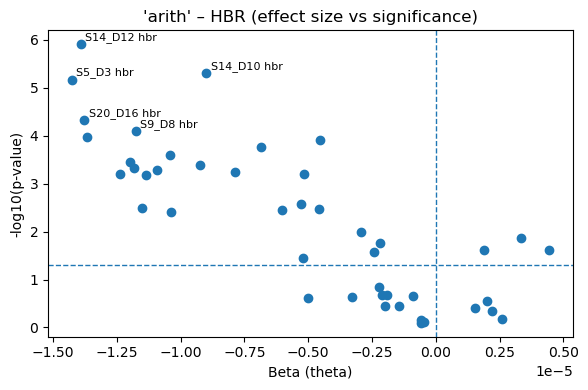

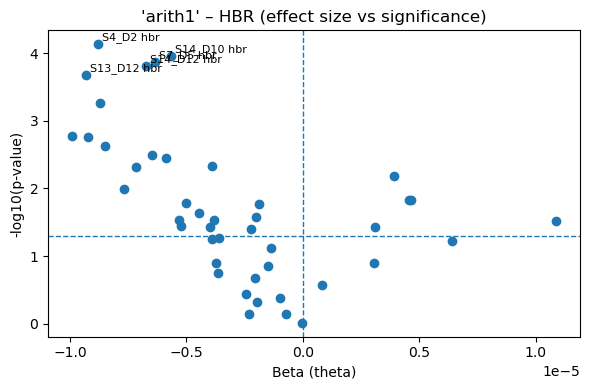


Done. Figures have been displayed.


In [113]:
# Expected CSV columns:
#   Condition, Chroma, ch_name, theta, p_value, ...

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) INPUTS
# -----------------------------
out_csv = "/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean_glm_mne.csv"
CSV_PATH = Path(out_csv)


ALPHA = 0.05  # p-value threshold

conditions_of_interest = ["arith", "arith1", "control"]

# -----------------------------
# 1) LOAD DATA
# -----------------------------
print(f"Loading GLM results from: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

print("\nColumns in file:")
print(df.columns.tolist())

required_cols = {"Condition", "Chroma", "ch_name", "theta", "p_value"}
missing = required_cols.difference(df.columns)
if missing:
    raise RuntimeError(f"CSV is missing columns: {missing}")

# Force string columns to string (prevents weird comparisons)
df["Condition"] = df["Condition"].astype(str).str.strip()
df["Chroma"] = df["Chroma"].astype(str).str.strip().str.lower()
df["ch_name"] = df["ch_name"].astype(str).str.strip()

print("\nUnique conditions in CSV:")
print(sorted(df["Condition"].unique().tolist()))
print("\nUnique chroma in CSV:")
print(sorted(df["Chroma"].unique().tolist()))

# -----------------------------
# 2) SUMMARY: SIGNIFICANT CHANNELS
# -----------------------------
sig = df[df["p_value"] < ALPHA]
summary = (
    sig.groupby(["Condition", "Chroma"])["ch_name"]
       .nunique()
       .reset_index(name="n_sig_channels")
)
print(f"\nNumber of significant channels (p < {ALPHA:.3f}) per condition & chroma:")
print(summary.to_string(index=False))

# -----------------------------
# Helper
# -----------------------------
def _order_channels(sub_df: pd.DataFrame) -> pd.DataFrame:
    """Sort by channel name and set ch_name as index (keeps 1 row per ch_name if already unique)."""
    return sub_df.sort_values("ch_name").set_index("ch_name")

# -----------------------------
# 3) BAR PLOTS: BETAS PER CHANNEL (ARITH vs ARITH1 vs CONTROL)
# -----------------------------
print("\nCreating grouped bar plots for 'arith', 'arith1', and 'control' betas per channel...")

chroma_list = sorted(df["Chroma"].unique())
for chroma in chroma_list:
    df_ch = df[(df["Chroma"] == chroma) & (df["Condition"].isin(conditions_of_interest))]

    if df_ch.empty:
        print(f"  - Skipping chroma '{chroma}': no rows for the selected conditions.")
        continue

    df_arith  = _order_channels(df_ch[df_ch["Condition"] == "arith"])
    df_arith1 = _order_channels(df_ch[df_ch["Condition"] == "arith1"])
    df_ctrl   = _order_channels(df_ch[df_ch["Condition"] == "control"])

    # Require all 3 to compare apples-to-apples
    if df_arith.empty or df_arith1.empty or df_ctrl.empty:
        print(f"  - Skipping chroma '{chroma}': missing one of arith/arith1/control.")
        continue

    # Align by common channels present in all three
    common_channels = df_arith.index.intersection(df_arith1.index).intersection(df_ctrl.index)
    if len(common_channels) == 0:
        print(f"  - Skipping chroma '{chroma}': no common channels across all 3 conditions.")
        continue

    df_arith  = df_arith.loc[common_channels]
    df_arith1 = df_arith1.loc[common_channels]
    df_ctrl   = df_ctrl.loc[common_channels]

    x = np.arange(len(common_channels))
    width = 0.27  # 3 bars -> narrower width

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, df_arith["theta"],  width, label="arith")
    ax.bar(x,         df_arith1["theta"], width, label="arith1")
    ax.bar(x + width, df_ctrl["theta"],   width, label="control")

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(common_channels, rotation=90)
    ax.set_ylabel("Beta (theta)")
    ax.set_title(f"GLM betas per channel – {chroma.upper()} (arith vs arith1 vs control)")
    ax.legend()
    fig.tight_layout()
    plt.show()

# -----------------------------
# 4) HEATMAP: HbO BETAS (ARITH/ARITH1/CONTROL)
# -----------------------------
print("\nCreating heatmap of HbO betas (arith/arith1/control)...")

if "hbo" in df["Chroma"].unique():
    df_hbo = df[(df["Chroma"] == "hbo") & (df["Condition"].isin(conditions_of_interest))]
    if not df_hbo.empty:
        heat = df_hbo.pivot(index="ch_name", columns="Condition", values="theta")

        # Keep columns in your desired order (if present)
        cols_present = [c for c in conditions_of_interest if c in heat.columns]
        heat = heat[cols_present].sort_index()

        fig, ax = plt.subplots(figsize=(5, max(4, len(heat) * 0.2)))
        im = ax.imshow(heat.values, aspect="auto")

        ax.set_xticks(np.arange(heat.shape[1]))
        ax.set_xticklabels(heat.columns)
        ax.set_yticks(np.arange(heat.shape[0]))
        ax.set_yticklabels(heat.index)

        ax.set_title("Betas per channel – HbO (arith vs arith1 vs control)")
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Beta (theta)")

        fig.tight_layout()
        plt.show()
    else:
        print("No HbO rows for arith/arith1/control found in CSV.")
else:
    print("No HbO data in CSV – skipping heatmap.")

# -----------------------------
# 5) VOLCANO PLOTS: ARITH and ARITH1 (BETA vs -log10(p))
# -----------------------------
print("\nCreating volcano-style scatter for 'arith' and 'arith1'...")

for chroma in chroma_list:
    for cond in ["arith", "arith1"]:
        df_cond = df[(df["Condition"] == cond) & (df["Chroma"] == chroma)]
        if df_cond.empty:
            continue

        p = df_cond["p_value"].clip(lower=1e-10)
        neg_log_p = -np.log10(p)

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.scatter(df_cond["theta"], neg_log_p)

        ax.axvline(0.0, linestyle="--", linewidth=1)
        ax.axhline(-np.log10(ALPHA), linestyle="--", linewidth=1)

        ax.set_xlabel("Beta (theta)")
        ax.set_ylabel("-log10(p-value)")
        ax.set_title(f"'{cond}' – {chroma.upper()} (effect size vs significance)")

        # Label top 5 most significant
        top = df_cond.assign(neg_log_p=neg_log_p).nlargest(5, "neg_log_p")
        for _, row in top.iterrows():
            ax.annotate(
                row["ch_name"],
                (row["theta"], -np.log10(max(row["p_value"], 1e-10))),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=8,
            )

        fig.tight_layout()
        plt.show()

print("\nDone. Figures have been displayed.")


## GLM from multiple runs
Outputs the glm metrics for each channel to a .csv file

Found runs:
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-2_nirs_with_events_preproc_hb_mne_clean.snirf
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_run-3_nirs_with_events_preproc_hb_mne_clean.snirf
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived/sub-bndy_ses-tp1_task-arith_ru

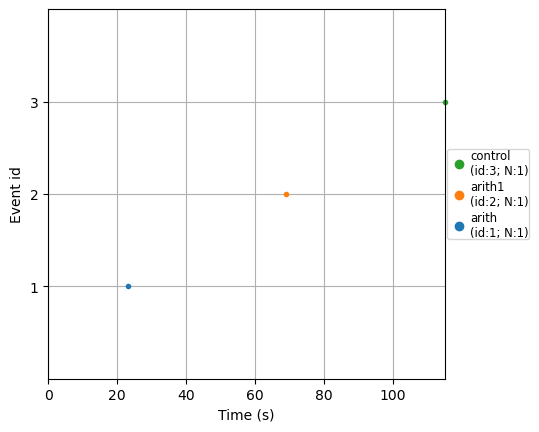

annotations for run 2 :
 <Annotations | 3 segments: arith (1), arith1 (1), control (1)> 


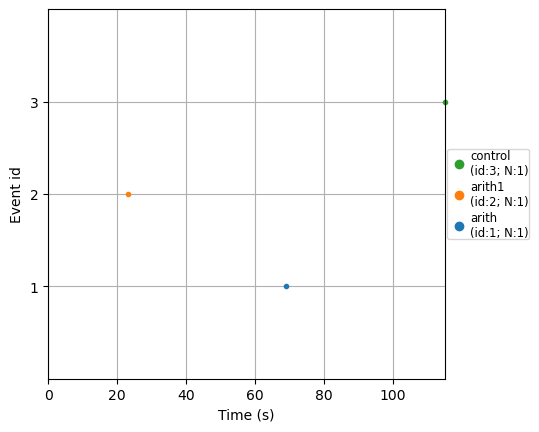

annotations for run 3 :
 <Annotations | 3 segments: arith (1), arith1 (1), control (1)> 


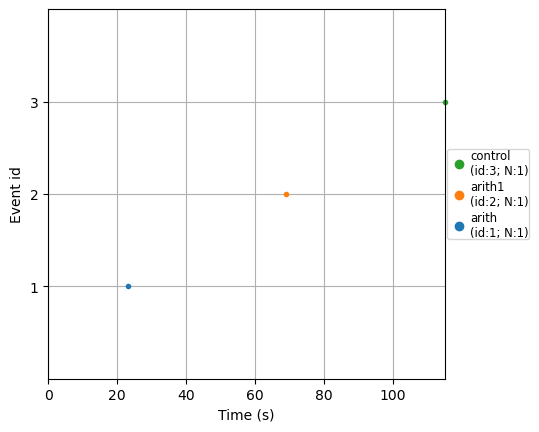

annotations for run 4 :
 <Annotations | 3 segments: arith (1), arith1 (1), control (1)> 


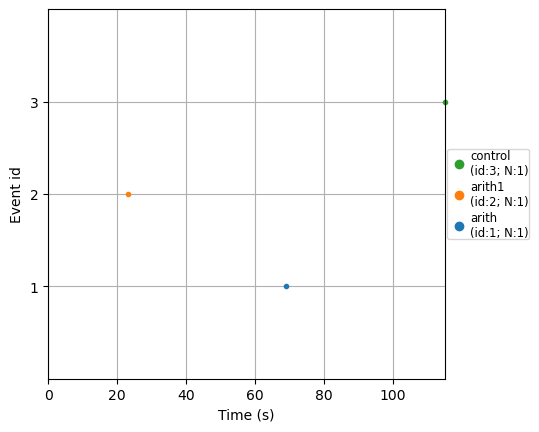

annotations for combined runs :
 <Annotations | 18 segments: BAD boundary (3), EDGE boundary (3), arith ...> 
23.049465 36.0 arith
69.025444 36.0 arith1
115.034848 36.0 control
174.0 0.0 BAD boundary
174.0 0.0 EDGE boundary
197.044506 36.0 arith1
242.993076 36.0 arith
288.987239 36.0 control
346.9 0.0 BAD boundary
346.9 0.0 EDGE boundary
369.944823 36.0 arith
415.906515 36.0 arith1
461.918998 36.0 control
520.9 0.0 BAD boundary
520.9 0.0 EDGE boundary
543.94326 36.0 arith1
589.907039 36.0 arith
635.902515 36.0 control


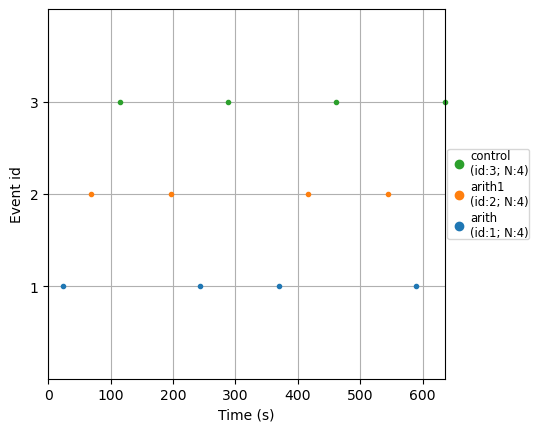

Subject-level design matrix columns:
['arith', 'arith_derivative', 'arith1', 'arith1_derivative', 'control', 'control_derivative', 'ShortHbO', 'ShortHbR', 'drift_1_run1', 'drift_2_run1', 'drift_3_run1', 'constant_run1', 'drift_1_run2', 'drift_2_run2', 'drift_3_run2', 'constant_run2', 'drift_1_run3', 'drift_2_run3', 'drift_3_run3', 'constant_run3', 'drift_1_run4', 'drift_2_run4', 'drift_3_run4', 'constant_run4']
     arith  arith_derivative  arith1  arith1_derivative  control  \
0.0    0.0               0.0     0.0                0.0      0.0   
0.1    0.0               0.0     0.0                0.0      0.0   
0.2    0.0               0.0     0.0                0.0      0.0   
0.3    0.0               0.0     0.0                0.0      0.0   
0.4    0.0               0.0     0.0                0.0      0.0   

     control_derivative  ShortHbO      ShortHbR  drift_1_run1  drift_2_run1  \
0.0                 0.0 -0.000019  5.528229e-07      0.033903      0.033903   
0.1               

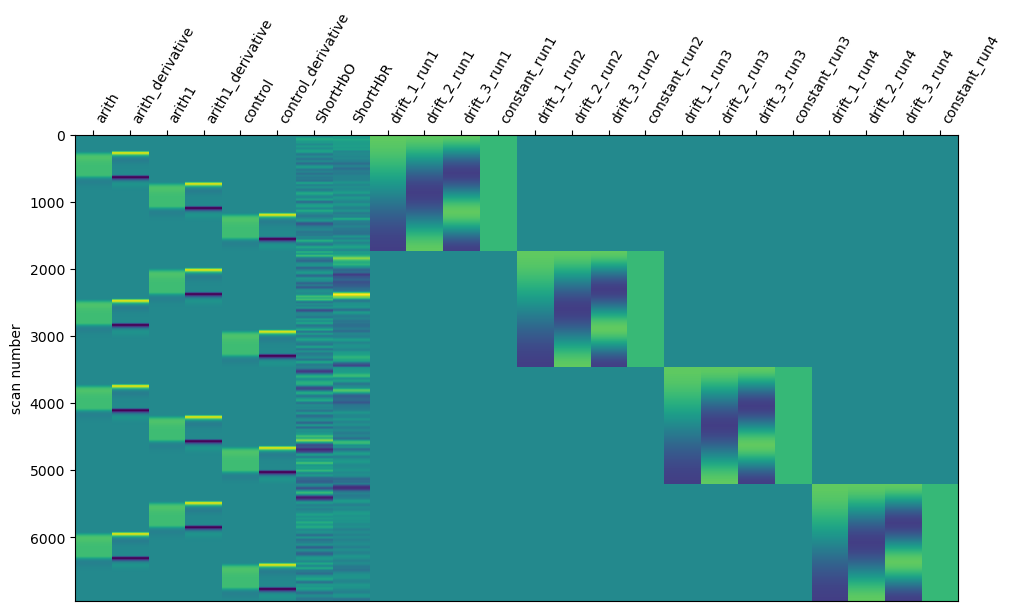

In [114]:

from pathlib import Path
import numpy as np
import pandas as pd
import mne

from mne.preprocessing.nirs import optical_density, beer_lambert_law
from mne_nirs.channels import get_long_channels
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm
import os

import matplotlib.pyplot as plt
import mne
import numpy as np
from nilearn.plotting import plot_design_matrix

import mne_nirs
from mne_nirs.channels import get_long_channels, get_short_channels, picks_pair_to_idx
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm


# -----------------------------
# Helpers
# -----------------------------
def _drop_bad_annotations(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
    """Remove boundary/bad annotations so they don't become regressors."""
    ann = raw.annotations
    if ann is None or len(ann) == 0:
        return raw
    keep = [not str(d).upper().startswith("BAD") for d in ann.description]
    raw.set_annotations(ann[keep])
    return raw


def _infer_stim_dur(raw: mne.io.BaseRaw, fallback: float = 5.0) -> float:
    """Pick a reasonable block duration from annotations."""
    if raw.annotations is None or len(raw.annotations) == 0:
        return fallback
    durs = np.asarray(raw.annotations.duration, dtype=float)
    durs = durs[np.isfinite(durs) & (durs > 0)]
    return float(np.median(durs)) if len(durs) else fallback


def load_prepare_run(snirf_path: Path) -> mne.io.BaseRaw:
    """
    Load one run SNIRF, ensure HbO/HbR, keep long channels, clean annotations.
    """
    raw = mne.io.read_raw_snirf(snirf_path, preload=True)
    raw = _drop_bad_annotations(raw)

    ch_types = raw.get_channel_types(unique=True)

    if "fnirs_cw_amplitude" in ch_types:
        raw_od = optical_density(raw)
        raw_hb = beer_lambert_law(raw_od)
    elif any(ct in ("hbo", "hbr") for ct in ch_types):
        raw_hb = raw.copy()
    else:
        raise RuntimeError(
            f"{snirf_path.name}: Unexpected channel types {ch_types}. "
            "Expected 'fnirs_cw_amplitude' or 'hbo'/'hbr'."
        )

    #raw_hb.annotations.rename({"arith1": "arith"})

    short_chs = get_short_channels(raw_hb)
    raw_hb = get_long_channels(raw_hb)

    print("Short channel count :", len(short_chs.ch_names))
    print("\nShort channels :", short_chs.ch_names)
    print("\nLong channel count:", len(raw_hb.ch_names))
    print("Long channels :", raw_hb.ch_names)



    raw_hb = _drop_bad_annotations(raw_hb)  # again after transforms (safe)
    return raw_hb, short_chs


def build_subject_design_matrix_from_run_dms(
    run_dms: list[pd.DataFrame],
    run_n_times: list[int],
    sfreq: float,
) -> pd.DataFrame:

    def split_cols(dm: pd.DataFrame):
        nuisance = [c for c in dm.columns if (c == "constant" or str(c).startswith("drift"))]
        cond = [c for c in dm.columns if c not in nuisance]
        return cond, nuisance

    # Union of all condition columns across runs (shared effects)
    cond_union = []
    for dm in run_dms:
        cond_cols, _ = split_cols(dm)
        for c in cond_cols:
            if c not in cond_union:
                cond_union.append(c)

    offset = 0
    dm_blocks = []

    for i, dm in enumerate(run_dms, start=1):
        dm = dm.copy()

        # Sanity check: DM rows should match data samples for that run
        if dm.shape[0] != run_n_times[i - 1]:
            raise RuntimeError(
                f"Run {i}: design matrix rows ({dm.shape[0]}) != raw.n_times ({run_n_times[i-1]})."
            )

        # Ensure all shared condition columns exist in this run
        for c in cond_union:
            if c not in dm.columns:
                dm[c] = 0.0

        cond_cols, nuisance_cols = split_cols(dm)

        # Rename nuisance columns to be run-specific
        rename_map = {c: f"{c}_run{i}" for c in nuisance_cols}
        dm = dm.rename(columns=rename_map)

        # Keep columns in a consistent order
        dm = dm[cond_union + [rename_map[c] for c in nuisance_cols]]

        # IMPORTANT: use sample index directly (0..n_times-1), then offset
        dm.index = np.arange(run_n_times[i - 1]) + offset
        offset += run_n_times[i - 1]

        dm_blocks.append(dm)

    total_n = int(sum(run_n_times))

    # Stack runs in time; missing columns become NaN -> we fix that
    dm_subject = pd.concat(dm_blocks, axis=0, sort=False).sort_index()

    # Ensure every sample exists (0..total_n-1)
    dm_subject = dm_subject.reindex(np.arange(total_n), fill_value=0.0)

    # convert NaNs (from “columns absent in that run”) into zeros
    dm_subject = dm_subject.fillna(0.0).astype(float)

    # index in seconds (nice for plotting)
    dm_subject.index = dm_subject.index / sfreq

    return dm_subject



# -----------------------------
# MAIN
# -----------------------------
# 1) List all run files for this subject

path_str = "/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/snirf_files_with_correct_stim_events_BNDY/preproc_for_mne/mne_derived"
runs_dir = Path(path_str)

run_paths = sorted(runs_dir.glob("*.snirf"))

print("Found runs:")
for p in run_paths:
    print(p)

out_csv = runs_dir / "mne_derived" / "subject_level_glm_mne.csv"
out_csv.parent.mkdir(exist_ok=True)
print(out_csv)


# 2) Load + prep each run
raw_runs = []; short_chs_runs = [];
for p in run_paths:

    raw_hb, short_chs = load_prepare_run(p)

    short_chs_runs.append(short_chs)
    raw_runs.append(raw_hb)
    

# 3) Make sure channel sets match across runs (use common channels, keep same order)
common = set(raw_runs[0].ch_names)
for r in raw_runs[1:]:
    common &= set(r.ch_names)

if len(common) == 0:
    raise RuntimeError("No common channels across runs after long-channel selection.")

common_order = [ch for ch in raw_runs[0].ch_names if ch in common]
raw_runs = [r.copy().pick_channels(common_order) for r in raw_runs]

# View experiment events
for i in range(len(raw_runs)):

    print("annotations for run {} :\n {} ".format(i+1, raw_runs[i].annotations))
    events, event_dict = mne.events_from_annotations(raw_runs[i], verbose=False)
    mne.viz.plot_events(events, event_id=event_dict, sfreq=raw_runs[i].info["sfreq"])
    

# 4) Check sampling frequency is consistent
sfreqs = [r.info["sfreq"] for r in raw_runs]
if not np.allclose(sfreqs, sfreqs[0]):
    raise RuntimeError(f"Different sampling rates across runs: {sfreqs}. Resample to match first.")
sfreq = float(sfreqs[0])

# 5) Build run-level design matrices (one per run)
run_dms = []
run_n_times = []

for i, raw in enumerate(raw_runs):

    stim_dur = _infer_stim_dur(raw, fallback=5.0)

    dm = make_first_level_design_matrix(
    raw,
    drift_model="cosine",
    high_pass=0.01,
    hrf_model="spm + derivative",
    stim_dur=stim_dur
    )

    dm["ShortHbO"] = np.mean(
    short_chs_runs[i].copy().pick(picks="hbo").get_data(), axis=0
    )

    dm["ShortHbR"] = np.mean(
    short_chs_runs[i].copy().pick(picks="hbr").get_data(), axis=0
    )

    
    run_dms.append(dm)
    run_n_times.append(raw.n_times)

# 6) Concatenate raws (subject/session time series)
raw_all = mne.concatenate_raws([r.copy() for r in raw_runs], preload=True)

print("annotations for combined runs :\n {} ".format(raw_all.annotations))
for onset, duration, desc in zip(
    raw_all.annotations.onset,
    raw_all.annotations.duration,
    raw_all.annotations.description
):
    print(onset, duration, desc)
    
events, event_dict = mne.events_from_annotations(raw_all, verbose=False)
mne.viz.plot_events(events, event_id=event_dict, sfreq=raw_all.info["sfreq"])

# 7) Build subject-level design matrix FROM the run-level design matrices
dm_subject = build_subject_design_matrix_from_run_dms(run_dms, run_n_times, sfreq)

#Plot design matrix
fig, ax1 = plt.subplots(figsize=(10, 6), constrained_layout=True)
fig = plot_design_matrix(dm_subject, axes=ax1)

print("Subject-level design matrix columns:")
print(list(dm_subject.columns))
print(dm_subject.head())

n_nans = int(dm_subject.isna().sum().sum())
print("NaNs in design matrix:", n_nans)


# 8) Fit GLM on concatenated data
glm_est = run_glm(raw_all, dm_subject)


# 9) Export
df = glm_est.to_dataframe()
print("df dimensions", df.shape)
df.to_csv(out_csv, index=False)
print(f"Saved subject-level GLM results to: {out_csv}")

## Pick best channel based on metrics

1. maximum |t| value
2. minimum p-value
3. maximum |theta| value

In [115]:
import numpy as np

def pick_best_channel(
    df,
    condition="arith",
    chroma="hbo",
    metric="abs_t",          # "abs_t" | "min_p" | "abs_theta"
    p_max=None,              # e.g. 0.05 to only consider significant
    theta_sign=None,         # "pos" | "neg" | None
    exclude_nuisance=True,   # drop drift/constant/Short/derivative if you want
):
    d = df.copy()

    # filter to condition + chroma
    d = d[(d["Condition"] == condition) & (d["Chroma"] == chroma)]

    # optional: restrict by p-value
    if p_max is not None:
        d = d[d["p_value"] <= p_max]

    # optional: restrict by theta sign
    if theta_sign == "pos":
        d = d[d["theta"] > 0]
    elif theta_sign == "neg":
        d = d[d["theta"] < 0]

    # optional: exclude nuisance-like rows (mainly useful if condition list is broader)
    if exclude_nuisance:
        bad_prefix = ("Short", "drift", "constant")
        d = d[~d["Condition"].str.startswith(bad_prefix)]
        # Usually you DO want derivatives when plotting “condition-only”.
        # If you want to exclude them from selection, uncomment:
        # d = d[~d["Condition"].str.endswith("_derivative")]

    if len(d) == 0:
        raise ValueError("No rows left after filtering. Loosen p_max/theta_sign or check condition/chroma names.")

    # choose best
    if metric == "abs_t":
        idx = d["t"].abs().idxmax()
    elif metric == "min_p":
        idx = d["p_value"].idxmin()
    elif metric == "abs_theta":
        idx = d["theta"].abs().idxmax()
    else:
        raise ValueError("metric must be one of: 'abs_t', 'min_p', 'abs_theta'")

    row = d.loc[idx]
    return row["ch_name"], row


df = glm_est.to_dataframe()

# 1) Best by strongest evidence (max |t|)
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="abs_t")
print("Best (abs_t):", ch_name, row[["theta","t","p_value"]].to_dict())

# 2) Best by smallest p-value
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="min_p")
print("Best (min_p):", ch_name, row[["theta","t","p_value"]].to_dict())

# 3) Best by largest effect size (max |theta|)
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="abs_theta")
print("Best (abs_theta):", ch_name, row[["theta","t","p_value"]].to_dict())

# Optional: only significant + positive HbO
# ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="abs_t", p_max=0.05, theta_sign="pos")


Best (abs_t): S18_D15 hbo {'theta': 6.304180487841417e-05, 't': 15.235009486741607, 'p_value': 7.735254367161266e-14}
Best (min_p): S18_D15 hbo {'theta': 6.304180487841417e-05, 't': 15.235009486741607, 'p_value': 7.735254367161266e-14}
Best (abs_theta): S10_D8 hbo {'theta': 0.00012926978437222337, 't': 11.92319800911666, 'p_value': 1.427383209402533e-11}


## Plot the hemodynamic response for different triggers, for a given channel.

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


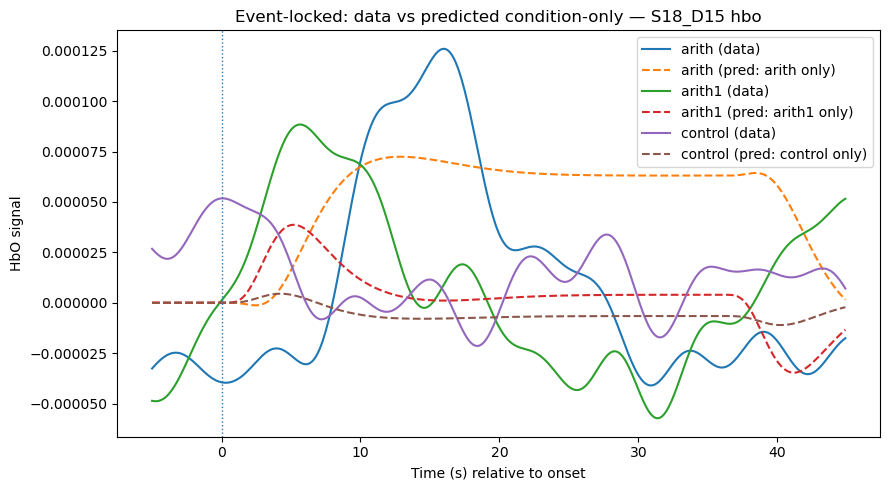

In [116]:
import numpy as np
import matplotlib.pyplot as plt

def betas_for_channel(df, ch_name):
    sub = df[df["ch_name"] == ch_name].copy()
    return sub.set_index("Condition")["theta"]

def predict_from_columns(dm, betas, cols):
    cols = [c for c in cols if c in dm.columns and c in betas.index]
    X = dm[cols].to_numpy()
    b = betas.loc[cols].to_numpy()
    return X @ b

def event_onsets_from_annotations(raw, event_name):
    onsets_sec = [o for o, d in zip(raw.annotations.onset, raw.annotations.description) if d == event_name]
    return (np.array(onsets_sec) * raw.info["sfreq"]).astype(int)

def average_locked(y, onsets_samp, sfreq, tmin=-5.0, tmax=45.0):
    n_pre = int(round(abs(tmin) * sfreq))
    n_post = int(round(tmax * sfreq))
    win_len = n_pre + n_post
    epochs = []
    for o in onsets_samp:
        start, stop = o - n_pre, o + n_post
        if start < 0 or stop > len(y):
            continue
        epochs.append(y[start:stop])
    if not epochs:
        return None, None
    epochs = np.vstack(epochs)
    t = np.linspace(tmin, tmax, win_len, endpoint=False)
    return t, epochs.mean(axis=0)

# ---- inputs ----
df = glm_est.to_dataframe()
ch_name = "S18_D15 hbo"     # your channel
sfreq = raw_all.info["sfreq"]

df_ch = df[df["Chroma"] == "hbo"]
betas = betas_for_channel(df_ch, ch_name)

# measured data
y_true = raw_all.copy().pick_channels([ch_name]).get_data().ravel()

# predicted CONDITION contributions (only those regressors)
pred_arith   = predict_from_columns(dm_subject, betas, ["arith", "arith_derivative"])
pred_arith1  = predict_from_columns(dm_subject, betas, ["arith1", "arith1_derivative"])
pred_control = predict_from_columns(dm_subject, betas, ["control", "control_derivative"])

conds = {
    "arith":   pred_arith,
    "arith1":  pred_arith1,
    "control": pred_control,
}

plt.figure(figsize=(9,5))

for cond, y_pred_cond in conds.items():
    onsets = event_onsets_from_annotations(raw_all, cond)
    t, avg_true = average_locked(y_true, onsets, sfreq, tmin=-5, tmax=45)
    _, avg_pred = average_locked(y_pred_cond, onsets, sfreq, tmin=-5, tmax=45)
    if avg_true is None:
        continue
    plt.plot(t, avg_true, label=f"{cond} (data)")
    plt.plot(t, avg_pred, linestyle="--", label=f"{cond} (pred: {cond} only)")

plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("Time (s) relative to onset")
plt.ylabel("HbO signal")
plt.title(f"Event-locked: data vs predicted condition-only — {ch_name}")
plt.legend()
plt.tight_layout()
plt.show()
